In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv(r"D:\project 2 predictive\Reviews.csv")

# Clean column names
df.columns = df.columns.str.strip()

# Convert rating → sentiment
def convert_label(rating):
    if rating <= 2:
        return 0   # Negative
    elif rating == 3:
        return 1   # Neutral
    else:
        return 2   # Positive

df["label"] = df["Score"].apply(convert_label)

# Keep only required columns
df = df[["Text", "label"]]
df = df.rename(columns={"Text": "text"})

# Remove missing values
df = df.dropna()

# 🔥 Reduce size for speed
df = df.sample(2000, random_state=42)

print(df.head())

                                                     text  label
165256  Having tried a couple of other brands of glute...      2
231465  My cat loves these treats. If ever I can't fin...      2
427827  A little less than I expected.  It tends to ha...      1
433954  First there was Frosted Mini-Wheats, in origin...      0
70260   and I want to congratulate the graphic artist ...      2


In [2]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

train_texts = train_df["text"].tolist()
test_texts = test_df["text"].tolist()

train_labels = train_df["label"].tolist()
test_labels = test_df["label"].tolist()

print("Train size:", len(train_texts))
print("Test size:", len(test_texts))

Train size: 1600
Test size: 400


In [3]:
print(df.head())
print(df.columns)

   Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3   4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4   5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0                       0      1  1346976000   
2                     1                       1      4  1219017600   
3                     3                       3      2  1307923200   
4                     0                       0      5  1350777600   

                 Summary                                               Text  
0  Good Quality Dog Food  I have bought several of the Vitality canned d...  
1 

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

vectorizer = TfidfVectorizer(max_features=5000)

X_train = vectorizer.fit_transform(train_texts)
X_test = vectorizer.transform(test_texts)

svm_model = SVC(kernel='linear')
svm_model.fit(X_train, train_labels)

svm_preds = svm_model.predict(X_test)

print("\nSVM Results:")
print("Accuracy:", accuracy_score(test_labels, svm_preds))
print(classification_report(test_labels, svm_preds))


SVM Results:
Accuracy: 0.775
              precision    recall  f1-score   support

           0       0.72      0.21      0.33        62
           1       1.00      0.03      0.05        39
           2       0.78      0.99      0.87       299

    accuracy                           0.78       400
   macro avg       0.83      0.41      0.42       400
weighted avg       0.79      0.78      0.71       400



In [4]:
import torch
from transformers import DistilBertTokenizerFast

tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=128   # 🔥 important for speed
)

test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=128
)

In [5]:
import torch
from transformers import DistilBertTokenizerFast

tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=128   # 🔥 important for speed
)

test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=128
)

In [6]:
from torch.utils.data import Dataset

class MyDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = MyDataset(train_encodings, train_labels)
test_dataset = MyDataset(test_encodings, test_labels)

In [10]:
from transformers import DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=3
)



Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [15]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

model.train()

for epoch in range(3):   # 🔥 only 1 epoch
    print(f"\nEpoch {epoch+1}")
    
    for i, batch in enumerate(train_loader):
        batch = {k: v.to(device) for k, v in batch.items()}
        
        optimizer.zero_grad()
        outputs = model(**batch)
        loss = outputs.loss
        
        loss.backward()
        optimizer.step()
        
        # Print occasionally (not every step)
        if i % 50 == 0:
            print("Loss:", loss.item())


Epoch 1
Loss: 0.3233552873134613
Loss: 0.14963418245315552

Epoch 2
Loss: 0.14656275510787964
Loss: 0.032456349581480026

Epoch 3
Loss: 0.029616156592965126
Loss: 0.005598936229944229


In [16]:
from sklearn.metrics import accuracy_score

model.eval()

predictions = []
true_labels = []

with torch.no_grad():
    for batch in DataLoader(test_dataset, batch_size=16):
        batch = {k: v.to(device) for k, v in batch.items()}
        
        outputs = model(**batch)
        logits = outputs.logits
        
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        labels = batch["labels"].cpu().numpy()
        
        predictions.extend(preds)
        true_labels.extend(labels)

print("\nBERT Results:")
print("Accuracy:", accuracy_score(true_labels, predictions))


BERT Results:
Accuracy: 0.8175


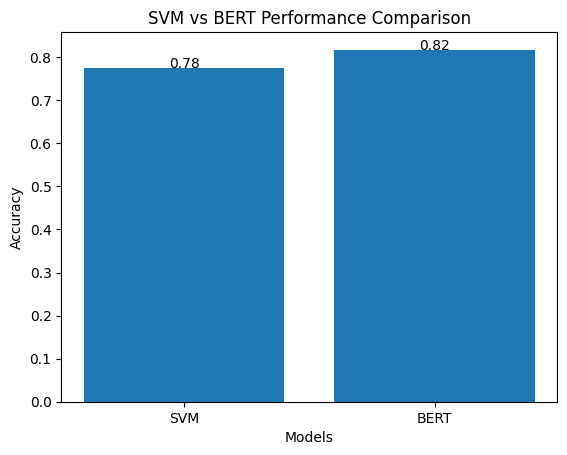

In [17]:
import matplotlib.pyplot as plt

# 🔥 Replace with your actual values
models = ["SVM", "BERT"]
accuracies = [0.775, 0.8175]   # <-- change SVM value here

plt.figure()
plt.bar(models, accuracies)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("SVM vs BERT Performance Comparison")

# Show values on top
for i, v in enumerate(accuracies):
    plt.text(i, v, f"{v:.2f}", ha='center')

plt.show()

In [18]:
import joblib

# Save SVM model
joblib.dump(svm_model, "svm_model.pkl")

# Save TF-IDF vectorizer
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("SVM model saved ✅")

SVM model saved ✅


In [19]:
# Save BERT model
model.save_pretrained("bert_model")

# Save tokenizer
tokenizer.save_pretrained("bert_model")

print("BERT model saved ✅")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BERT model saved ✅


In [20]:
import joblib

svm_model = joblib.load("svm_model.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")

In [21]:
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification

tokenizer = DistilBertTokenizerFast.from_pretrained("bert_model")
model = DistilBertForSequenceClassification.from_pretrained("bert_model")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [22]:
sample = ["This product is amazing!"]

# SVM prediction
X = vectorizer.transform(sample)
print("SVM:", svm_model.predict(X))

# BERT prediction
inputs = tokenizer(sample, return_tensors="pt", truncation=True, padding=True)
outputs = model(**inputs)
pred = outputs.logits.argmax(dim=1).item()

print("BERT:", pred)

SVM: [2]
BERT: 2
